In [130]:
import pandas as pd
import seaborn as sb
import pingouin as pg
import os
import scipy.stats as stats
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.style.use('/Users/amonast/Documents/GitHub/Amy_Reviews/paper_style.mplstyle')

savepath = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure4_Supp5'

In [131]:
def load_pairwise_df_all(bin_size): ### get the pairwise correlations for whole time. 
    '''
    bin_size: dataframes to load based on bin size in frame
    '''
    path=f'/Volumes/AM_SSD1/Spont2P/Analysis/correlation/pairwise_dataframes_reg_tot/0_lag/{bin_size}_bin'
    df_pre = pd.read_csv(os.path.join(path,'pairwise_corr_df_pre.csv'),index_col=0)
    df_post = pd.read_csv(os.path.join(path, 'pairwise_corr_df_post.csv'),index_col=0)

    return df_pre,df_post

def fisher_z_transform(r):
    """
    Apply Fisher z-transform to a correlation coefficient (r).
    
    Parameters:
        r (float or ndarray): Pearson or Spearman correlation coefficient(s).
        
    Returns:
        float or ndarray: Fisher z-transformed value(s).
    """
    return 0.5 * np.log((1 + r) / (1 - r))

def change_corr_bins_rest(bins):
    '''
    bins: list or array of bin sizes
    drop any non-firing cells 

    '''
    df_all = pd.DataFrame()
    for b in bins:
        df_pre0,df_post0 = load_pairwise_df_all(b)
        # Create a mask to check where 999 appears in either df_pre0 or df_post0
        mask_999 = (df_pre0 == 999) | (df_post0 == 999)
        # Get the indices of the rows with 999 in either dataframe
        rows_with_999 = mask_999.any(axis=1)
        # Remove these rows from df_cleaned
        df_post= df_post0[~rows_with_999]
        df_pre= df_pre0[~rows_with_999]
        abs_change = np.abs(df_post['Spearmans R']-df_pre['Spearmans R'])
        change = df_post['Spearmans R']-df_pre['Spearmans R']
        Z_change =df_post['ZScored Spearmans R']-df_pre['ZScored Spearmans R']
        Z_abs=np.abs(df_post['ZScored Spearmans R']-df_pre['ZScored Spearmans R'])
        df = df_pre.copy()
        df = df.drop(['Session','ZScored Spearmans R','pvals'],axis=1)
        df['deltaR(abs)'] = abs_change
        df['deltaR']=change
        df['deltaZScored']=Z_change
        df['absZ']=Z_abs
        df['Bin Size']=b*1/30
        df_all=pd.concat([df_all,df],ignore_index=False)
    return df_all

def zscore_change_rest(df_change):
    '''
    drop any non-firing cells 
    '''
    bins = np.unique(df_change['Bin Size'])
    zscored_all=[]
    zscored_persession=[]
    zabs_all=[]
    for b in bins: #within bin sizes
        df_b = df_change.loc[df_change['Bin Size']==b]
        zscored=[]
        fisherz=[]
        zscored_session=[]
        zabs=[]
        for ani in df_b.Animal.unique(): #within each animal
            df_a = df_b.loc[df_b.Animal==ani]
            zscored.extend(stats.zscore(df_a['deltaR'])) #ZScore the change in coefficient
            zscored_session.extend(df_a['deltaZScored'])
            fisherz.extend(fisher_z_transform(df_a['deltaR']))
            zabs.extend(df_a['absZ'])
        zscored_all.extend(zscored)
        zscored_persession.extend(zscored_session)
        zabs_all.extend(zabs)
    df_change.drop(['deltaZScored','absZ'],axis=1,inplace=True)
    df_change['deltaR_Zscore']=zscored_all
    df_change['ZScored deltaR Session']=zscored_persession
    df_change['|deltaR|']=zabs_all
    return df_change

In [132]:
bins = [4,8,10,16,20,25,32,40, 50, 64, 80, 100, 125]
df_all=pd.DataFrame()
for b in bins:
    df_pre,df_post = load_pairwise_df_all(b)
    df = pd.concat([df_pre,df_post],ignore_index=True)
    df['Bin Size (s)'] = np.round(b*1/30,decimals=3)
    df_all = pd.concat([df_all,df],ignore_index=True)

In [133]:
df_cleaned = df_all[~df_all.eq(999).any(axis=1)]

df = df_cleaned.groupby(['Group','Animal','Session','Pair Group','Bin Size (s)']).mean().reset_index()
df['labels']=df['Pair Group'].map({'Tagged vs Tagged':'EE','Tagged vs Non-tagged':'EN','Non-tagged vs Non-tagged':'NN'})
df['session']=df['Session'].map({'Baseline':'D0','Post':'D4'})
df['FisherZ']=fisher_z_transform(df['Spearmans R'])

In [134]:
df2=change_corr_bins_rest(bins)
df3 = zscore_change_rest(df2)
mean_change=df3.groupby(['Bin Size','Group','Animal', 'Pair Group']).mean(['deltaR(abs)','deltaR','deltaR_Zscore','ZScored deltaR Session','|deltaR|']).reset_index()
mean_change['fisherZ_all']=fisher_z_transform(mean_change['deltaR'])

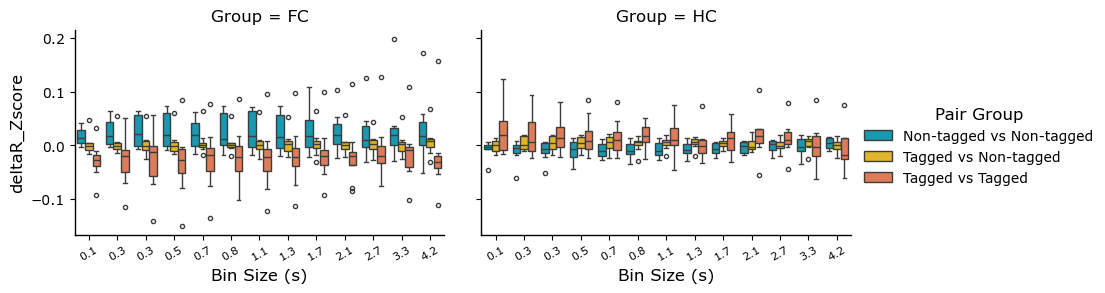

In [139]:
dv ='deltaR_Zscore'
g=sb.catplot(data=mean_change,y=dv,x='Bin Size',col='Group',hue='Pair Group',col_order=['FC','HC'],palette=palette2,dodge=True,kind='box',height=3,aspect=1.5,legend=True,fliersize=3,flierprops={"marker": "o"},fill=True)
plt.xticks(np.arange(0,len(bins)),labels=[str(np.round(b/30,1)) for b in bins],size=8)
g.set_xticklabels(rotation=30,size=8)
#plt.tight_layout()
plt.ylabel(r'$\Delta \ \ \rho \ \ \text{(z-scored)}$')
g.set_xlabels('Bin Size (s)')
plt.subplots_adjust(wspace=.1, hspace=0)
plt.savefig('Supp5D_Bins_boxplot_animals_rest.svg',transparent=True)

# SuppFig 6D plot

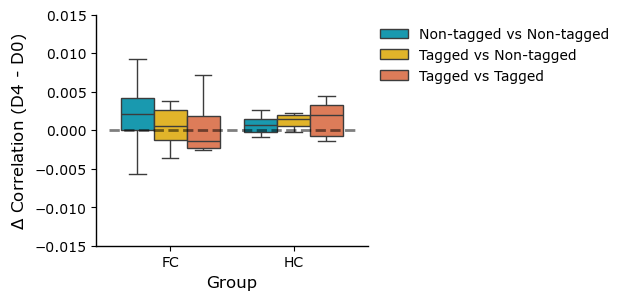

In [149]:
dv ='deltaR'

data = mean_change.loc[mean_change['Bin Size']==50/30]
fig,ax=plt.subplots(figsize=(3.5,3))
#sb.barplot(data=data,y=dv,x='Group',hue='Pair Group',ax=ax,palette=palette2,errorbar='se',linewidth=1,capsize=.2)
sb.boxplot(data=data,y=dv,x='Group',hue='Pair Group',ax=ax,palette=palette2,showfliers=False,legend=True)
#sb.stripplot(data=data,size=5,y=dv,x='Group',hue='Pair Group',edgecolor='#2a2d32',ax=ax,dodge=True,palette=palette2,linewidth=1,jitter=False,legend=False)
plt.hlines(0,-.5,1.5,colors='k',linestyles='dashed',linewidth=2,alpha=.5)
plt.ylabel('$\Delta$ Correlation (D4 - D0)')
# plt.hlines(0.006,.2,1.2,lw=1,color='k')
# plt.text(.7,0.0065,'p = 0.13',ha='center')
sb.despine()
#plt.title('Total',size=12)
plt.ylim([-0.015,.015])
plt.legend(frameon=False,bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f'{savepath}/boxplot_bin50_deltaR_tot.svg',transparent=True)

In [142]:
pg.normality(data,dv='deltaR',group='Group')

,W,pval,normal
Group,,,
FC,0.890112,0.013363,False
HC,0.973644,0.756666,True


In [143]:
pg.homoscedasticity(data,dv='deltaR',group='Pair Group')

,W,pval,equal_var
levene,1.455997,0.243942,True


In [144]:
data.columns = data.columns.str.replace(' ', '_')
data['Group']=pd.Categorical(data['Group'], categories=['HC', 'FC'], ordered=False)
data['Pair_Group']=data['Pair_Group'].astype('category')
formula = 'deltaR ~ C(Group) * C(Pair_Group)'


# Fit the mixed model
model = MixedLM.from_formula(
    formula,
    data=data,
    groups=data['Animal']  # Random effect for animal identity
)
result=model.fit()
# Print the summary of the model
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                           MixedLM              Dependent Variable:              deltaR  
No. Observations:                48                   Method:                          REML    
No. Groups:                      16                   Scale:                           0.0000  
Min. group size:                 3                    Log-Likelihood:                  167.6819
Max. group size:                 3                    Converged:                       Yes     
Mean group size:                 3.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.000    0.001  0.214 0.831 -0.002  0.003
C(Group)[T.FC]                                        0.002    0.002  1.011 0.312 -0.002  0.006
C(Pair_Group)[T.Tagged vs Non-tagged]                 0.001    0.002  0.371 0.711 -0.003  0.004
C(Pair_Group)[T.Tagged vs Tagged]                     0.001    0.002  0.623 0.533 -0.003  0.005
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Non-tagged] -0.002    0.003 -0.867 0.386 -0.008  0.003
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Tagged]     -0.005    0.003 -1.835 0.066 -0.010  0.000
Group Var                                             0.000    0.001                           
===============================================================================================

"""

In [101]:
pg.mixed_anova(data=data,dv=dv,between='Group',within='Pair_Group',subject='Animal')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.000003,1,14,0.000003,0.331771,0.573762,0.023149,NaN
1,Pair_Group,0.000014,2,28,0.000007,0.393267,0.678518,0.027323,0.543715
2,Interaction,0.000050,2,28,0.000025,1.419885,0.258617,0.092081,NaN


In [102]:
pg.pairwise_tests(data=data,dv=dv,between='Group',within='Pair_Group',subject='Animal',parametric=True,padjust='fdr_bh')

,Contrast,Pair_Group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Pair_Group,-,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,True,0.695342,15.0,two-sided,0.497473,0.591172,fdr_bh,0.316,0.151046
1,Pair_Group,-,Non-tagged vs Non-tagged,Tagged vs Tagged,True,True,0.646057,15.0,two-sided,0.528003,0.591172,fdr_bh,0.307,0.280399
2,Pair_Group,-,Tagged vs Non-tagged,Tagged vs Tagged,True,True,0.548870,15.0,two-sided,0.591172,0.591172,fdr_bh,0.292,0.205370
3,Group,-,HC,FC,False,True,0.575995,14.0,two-sided,0.573762,NaN,NaN,0.479,0.272289
4,Pair_Group * Group,Non-tagged vs Non-tagged,HC,FC,False,True,-1.046426,14.0,two-sided,0.313096,0.469643,fdr_bh,0.616,-0.494674
5,Pair_Group * Group,Tagged vs Non-tagged,HC,FC,False,True,0.389750,14.0,two-sided,0.702586,0.702586,fdr_bh,0.45,0.184245
6,Pair_Group * Group,Tagged vs Tagged,HC,FC,False,True,1.194219,14.0,two-sided,0.252234,0.469643,fdr_bh,0.685,0.564540


In [103]:
from statsmodels.regression.mixed_linear_model import MixedLM

data=mean_change.copy()
data.columns = data.columns.str.replace(' ', '_')
data['Group']=pd.Categorical(data['Group'], categories=['HC', 'FC'], ordered=False)
data['Pair_Group']=data['Pair_Group'].astype('category')
data['Bin_Size']=data['Bin_Size'].astype('category')

# Construct the formula for the model (with interaction terms)
formula = 'deltaR ~ C(Group) * C(Pair_Group) + C(Bin_Size)'

# Fit the mixed model
model = MixedLM.from_formula(
    formula,
    data=data,
    groups=data['Animal']  # Random effect for animal identity
)
result=model.fit()
# Print the summary of the model
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                          MixedLM              Dependent Variable:              deltaR   
No. Observations:               624                  Method:                          REML     
No. Groups:                     16                   Scale:                           0.0000   
Min. group size:                39                   Log-Likelihood:                  2474.5879
Max. group size:                39                   Converged:                       Yes      
Mean group size:                39.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.000    0.001  0.310 0.756 -0.001  0.002
C(Group)[T.FC]                                        0.002    0.001  2.051 0.040  0.000  0.003
C(Pair_Group)[T.Tagged vs Non-tagged]                 0.000    0.001  0.796 0.426 -0.001  0.001
C(Pair_Group)[T.Tagged vs Tagged]                     0.001    0.001  1.979 0.048  0.000  0.002
C(Bin_Size)[T.0.26666666666666666]                    0.000    0.001  0.570 0.569 -0.001  0.002
C(Bin_Size)[T.0.3333333333333333]                     0.000    0.001  0.628 0.530 -0.001  0.002
C(Bin_Size)[T.0.5333333333333333]                     0.000    0.001  0.643 0.520 -0.001  0.002
C(Bin_Size)[T.0.6666666666666666]                     0.000    0.001  0.319 0.750 -0.001  0.002
C(Bin_Size)[T.0.8333333333333334]                     0.000    0.001  0.391 0.696 -0.001  0.002
C(Bin_Size)[T.1.0666666666666667]                     0.000    0.001  0.545 0.586 -0.001  0.002
C(Bin_Size)[T.1.3333333333333333]                     0.000    0.001  0.036 0.971 -0.001  0.002
C(Bin_Size)[T.1.6666666666666667]                     0.000    0.001  0.168 0.866 -0.001  0.002
C(Bin_Size)[T.2.1333333333333333]                     0.000    0.001  0.362 0.717 -0.001  0.002
C(Bin_Size)[T.2.6666666666666665]                     0.000    0.001  0.211 0.833 -0.001  0.002
C(Bin_Size)[T.3.3333333333333335]                     0.000    0.001  0.073 0.942 -0.001  0.002
C(Bin_Size)[T.4.166666666666667]                     -0.000    0.001 -0.050 0.960 -0.002  0.001
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Non-tagged] -0.002    0.001 -2.514 0.012 -0.003 -0.000
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Tagged]     -0.004    0.001 -6.048 0.000 -0.006 -0.003
Group Var                                             0.000    0.000                           
===============================================================================================

"""

In [104]:
data = mean_change.loc[mean_change['Bin Size']==4/30]
dv='deltaR_Zscore'
import pingouin as pg
pg.pairwise_tests(data=data,dv=dv,between='Group',within='Pair Group',subject='Animal',parametric=False,padjust='holm')

,Contrast,Pair Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,54.0,two-sided,0.495422,1.000000,holm,0.202008
1,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,57.0,two-sided,0.596588,1.000000,holm,0.126895
2,Pair Group,-,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,67.0,two-sided,0.979950,1.000000,holm,0.033623
3,Group,-,FC,HC,False,False,19.0,NaN,two-sided,0.194872,NaN,NaN,-0.781897
4,Pair Group * Group,Non-tagged vs Non-tagged,FC,HC,False,False,57.0,NaN,two-sided,0.006993,0.020979,holm,1.379906
5,Pair Group * Group,Tagged vs Non-tagged,FC,HC,False,False,29.0,NaN,two-sided,0.798446,0.798446,holm,0.190607
6,Pair Group * Group,Tagged vs Tagged,FC,HC,False,False,7.0,NaN,two-sided,0.006993,0.020979,holm,-1.285514


In [105]:
data = mean_change.loc[mean_change['Bin Size']==125/30]
dv='deltaR'
import pingouin as pg
pg.pairwise_tests(data=data,dv=dv,between='Group',within='Pair Group',subject='Animal',parametric=False,padjust='holm',within_first=False)

,Contrast,Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,33.0,NaN,two-sided,0.959130,NaN,NaN,0.125327
1,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,50.0,two-sided,0.375458,0.375458,holm,0.365225
2,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,33.0,two-sided,0.073914,0.221741,holm,0.417417
3,Pair Group,-,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,36.0,two-sided,0.104584,0.221741,holm,0.247909
4,Group * Pair Group,FC,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,13.0,two-sided,0.546875,1.000000,holm,0.523191
5,Group * Pair Group,FC,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,7.0,two-sided,0.148438,0.890625,holm,0.503685
6,Group * Pair Group,FC,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,7.0,two-sided,0.148438,0.890625,holm,0.298137
7,Group * Pair Group,HC,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,14.0,two-sided,0.640625,1.000000,holm,0.147595
8,Group * Pair Group,HC,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,12.0,two-sided,0.460938,1.000000,holm,0.241550
9,Group * Pair Group,HC,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,12.0,two-sided,0.460938,1.000000,holm,0.141597


In [106]:
data = mean_change.loc[mean_change['Bin Size']==125/30]
dv='deltaR'
import pingouin as pg
pg.mixed_anova(data=data,dv=dv,between='Group',within='Pair Group',subject='Animal')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.000004,1,14,0.000004,0.070286,0.794785,0.004995,NaN
1,Pair Group,0.000114,2,28,0.000057,0.995847,0.382119,0.066408,0.525898
2,Interaction,0.000042,2,28,0.000021,0.368555,0.695039,0.025650,NaN


In [107]:
pg.normality(data=data,dv='deltaR',group='Group')

,W,pval,normal
Group,,,
FC,0.833583,0.001100,False
HC,0.969772,0.661356,True


In [108]:
data['Group']=pd.Categorical(data['Group'], categories=['HC', 'FC'], ordered=False)
data['Pair_Group']=data['Pair Group'].astype('category')

model = MixedLM.from_formula(
    'deltaR ~ C(Group) * C(Pair_Group)',
    data=data,
    groups=data['Animal']  # Random effect for animal identity
)
result=model.fit()
# Print the summary of the model
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                           MixedLM              Dependent Variable:              deltaR  
No. Observations:                48                   Method:                          REML    
No. Groups:                      16                   Scale:                           0.0001  
Min. group size:                 3                    Log-Likelihood:                  138.7913
Max. group size:                 3                    Converged:                       Yes     
Mean group size:                 3.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.001    0.003  0.331 0.741 -0.004  0.006
C(Group)[T.FC]                                        0.003    0.004  0.731 0.465 -0.005  0.010
C(Pair_Group)[T.Tagged vs Non-tagged]                -0.001    0.004 -0.158 0.875 -0.008  0.007
C(Pair_Group)[T.Tagged vs Tagged]                    -0.001    0.004 -0.389 0.697 -0.009  0.006
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Non-tagged] -0.002    0.005 -0.377 0.706 -0.013  0.008
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Tagged]     -0.005    0.005 -0.857 0.392 -0.015  0.006
Group Var                                             0.000    0.001                           
===============================================================================================

"""